import importlib
import dnsmex
importlib.reload(dnsmex)
from dnsmex.dxsm_oe import OEPlotter

In [8]:
from collections import Counter

import torch
import tqdm
import altair as alt
import os
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

from natsort import natsorted
import logomaker

from netam import framework
from dnsmex import dxsm_data, dnsm_zoo, dasm_zoo
from dnsmex.dasm_oe import write_sites_oe, OEPlotter
from dnsmex.local import localify


from netam.common import heavy_chain_shim
from netam.framework import load_crepe, load_pcp_df
from netam.sequences import translate_sequence, AA_STR_SORTED

from dnsmex.dasm_viz import dms_style_heatmap
from dnsmex.local import localify
from dnsmex.dxsm_data import pcp_df_of_nickname

figures_dir = localify("FIGURES_DIR")

## Prep data - Rodriguez dataset

In [9]:
%%bash
## get counts of V and J genes
zcat /fh/fast/matsen_e/shared/bcr-mut-sel/pcps/v1/rodriguez-airr-seq-race-prod-InclMutInv_pcp_2024-11-12_MASKED_NI_noN_no-naive_addJ.csv.gz | tail -n +2 | cut -d ',' -f 11 | cut -d '-' -f 1 | sort | uniq -c | sort -nr
echo "---"
zcat /fh/fast/matsen_e/shared/bcr-mut-sel/pcps/v1/rodriguez-airr-seq-race-prod-InclMutInv_pcp_2024-11-12_MASKED_NI_noN_no-naive_addJ.csv.gz | tail -n +2 | cut -d ',' -f 20 | cut -d '*' -f 1 | sort | uniq -c | sort -nr

   9985 IGHV3
   5246 IGHV4
   4328 IGHV1
    944 IGHV5
    771 IGHV2
    351 IGHV6
    129 IGHV7
---
  11562 IGHJ4
   3563 IGHJ6
   2863 IGHJ5
   2825 IGHJ3
    562 IGHJ2
    379 IGHJ1


In [10]:
#dataset_name = "v1rodriguez_test"
dataset_name = "v1rodriguez"
model_name = "dasm_4m-v1jaffeCC+v1tangCC-joint"


crepe_prefix = localify(f"DASM_TRAINED_MODELS_DIR/{model_name}")
test_output_prefix = localify(f"DASM_TEST_OUTPUT_DIR/{model_name}-ON-{dataset_name}")

try: # load data if already computed
    
    site_sub_probs_df = pd.read_csv(f"{test_output_prefix}-site_sub_probs_df.csv")
    pcp_df = pd.read_csv(f"{test_output_prefix}-pcp_df.csv")
    aa_site_subs_selection_df = pd.read_csv(f"{test_output_prefix}-aa_site_subs_selection_df.csv")

except FileNotFoundError:
    if not os.path.exists(f"{test_output_prefix}.branch_lengths_csv"):
        dasm_zoo.write_branch_lengths(localify(f"DASM_TRAINED_MODELS_DIR/{model_name}"), dataset_name, f"{test_output_prefix}.branch_lengths_csv")


    complete_plotter, plotter_dict = write_sites_oe(
        crepe_prefix=crepe_prefix,
        dataset_name=dataset_name,
        branch_length_path=f"{test_output_prefix}.branch_lengths_csv",
        csv_output_path=f"{test_output_prefix}-sites-oe.csv",
        fig_out_path=f"{figures_dir}/sites-oe-V1,3,4.svg",
        min_log_prob=-4,
        #v_families=["IGHV1", "IGHV2", "IGHV3", "IGHV4", "IGHV5", "IGHV6", "IGHV7"],
        replace_title=True,
    )
    complete_plotter = complete_plotter["heavy"]

    pcp_df = complete_plotter.pcp_df.copy()
    site_sub_probs_df = complete_plotter.site_sub_probs_df.copy()
    aa_site_subs_selection_df = complete_plotter.aa_site_subs_selection_df.copy()

    pcp_df.to_csv(f"{test_output_prefix}-pcp_df.csv", index=False)
    site_sub_probs_df.to_csv(f"{test_output_prefix}-site_sub_probs_df.csv", index=False)
    aa_site_subs_selection_df.to_csv(f"{test_output_prefix}-aa_site_subs_selection_df.csv", index=False)



### preprocessing

    def site_sub_probs_df_without_low_freq(in_plotter, quantile_cutoff=0.05):
        site_sub_probs_df = in_plotter.site_sub_probs_df.copy()
        site_counts = site_sub_probs_df["site"].value_counts()
        cutoff = site_counts.quantile(quantile_cutoff)
        sites_above_cutoff = set(site_counts[site_counts > cutoff].index)
        site_sub_probs_df = site_sub_probs_df[site_sub_probs_df["site"].isin(sites_above_cutoff)]
        return site_sub_probs_df

    def sort_df_by_site(df):
        sorted_index = natsorted(df.index, key=lambda x: df.loc[x, 'site'])
        return df.iloc[sorted_index]

    def build_persite_df(site_sub_probs_df):
        persite_df = site_sub_probs_df.groupby(['site', 'is_cdr']).agg(
            mean_prob=('prob', 'mean'),
            mean_neutral_prob=('neutral_prob', 'mean'),
            mean_selection_factor=('selection_factor', 'mean'),
            mut_freq=('mutation', 'mean')
        ).reset_index()

        persite_df = sort_df_by_site(persite_df)

        return persite_df


In [11]:
site_sub_probs_df = pd.read_csv(f"{test_output_prefix}-site_sub_probs_df.csv")
pcp_df = pd.read_csv(f"{test_output_prefix}-pcp_df.csv")
aa_site_subs_selection_df = pd.read_csv(f"{test_output_prefix}-aa_site_subs_selection_df.csv")

In [12]:
pcp_df

,orig_pcp_idx,sample_id,family,parent_name,child_name,branch_length,depth,distance,parent_is_naive,child_is_leaf,...,v_gene,cdr1_codon_start,cdr1_codon_end,cdr2_codon_start,cdr2_codon_end,cdr3_codon_start,cdr3_codon_end,j_gene,v_family,parent_aa
0,16,sample-igg-SC-24,1401,Node1,1TGCGTTGTAGCT,0.082506,2,0.096444,False,True,...,IGHV7-4-1*02,75,96,150,171,288,333,IGHJ4*02,IGHV7,QVQLVQSGSELKKPGASVKVSCKASGYTFTSNAMNWVRQAPGQGLE...
1,17,sample-igg-SC-24,1401,Node1,Node2,0.018034,2,0.031971,False,False,...,IGHV7-4-1*02,75,96,150,171,288,333,IGHJ4*02,IGHV7,QVQLVQSGSELKKPGASVKVSCKASGYTFTSNAMNWVRQAPGQGLE...
2,32,sample-igg-SC-24,474,Node1,Node2,0.002823,2,0.079722,False,False,...,IGHV4-59*01,75,96,150,168,285,318,IGHJ4*02,IGHV4,QLQLQESGPGLVRPSETLSLTCSVSGGSMTYYYWSWIRQAPGKGLE...
3,45,sample-igg-SC-24,238,Node1,1GGGCACTATGCA,0.029887,2,0.094379,False,True,...,IGHV4-31*03,75,102,156,174,291,321,IGHJ6*02,IGHV4,QVQLQESGPGLVKPSQTLSLTCTVSGGSVSSGDYYWTWIRQFPGKG...
4,46,sample-igg-SC-24,238,Node1,1GCAGGGCACTCT,0.005211,2,0.069703,False,True,...,IGHV4-31*03,75,102,156,174,291,321,IGHJ6*02,IGHV4,QVQLQESGPGLVKPSQTLSLTCTVSGGSVSSGDYYWTWIRQFPGKG...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21747,311243,sample-igg-W-109,62,Node1,1TCGGCAATGTAT,0.002731,2,0.039758,False,True,...,IGHV1-8*02,75,96,150,171,288,330,IGHJ1*01,IGHV1,QVQLVQSGAEVKKPGASVKVSCKASGNSFTSYDINWVRQAAGQGLE...
21748,311261,sample-igg-W-109,10,Node1,Node2,0.002848,2,0.109737,False,False,...,IGHV3-7*01,75,96,150,171,288,315,IGHJ5*02,IGHV3,EAQLVESGGGLVQPGGSLRLSCAASGFTSRSHWMSWVRQAPGKGLE...
21749,311271,sample-igg-W-109,10,Node2,1TTTGTTCCTATG,0.002848,3,0.112585,False,True,...,IGHV3-7*01,75,96,150,171,288,315,IGHJ5*02,IGHV3,EAQLVESGGGLVQPGGSLRLSCAASGFTSRSHWMSWVRQAPGKGLE...
21750,311275,sample-igg-W-117,10,Node1,1AAAGGGCCAGTT,0.002803,2,0.119753,False,True,...,IGHV1-18*01,75,96,150,171,288,321,IGHJ4*02,IGHV1,QIQLVQSVSEVKKPGASVKVSCKASGYTFVNYVVSWVRQAPGQGLE...


In [13]:
site_sub_probs_df

,prob,mutation,pcp_index,site,is_cdr,parent_codon,parent_aa,child_codon,child_aa
0,0.012117,False,0,1.0,False,CAG,Q,CAG,Q
1,0.003648,False,1,1.0,False,CAG,Q,CAG,Q
2,0.002530,False,2,1.0,False,CAG,Q,CAG,Q
3,0.016663,False,3,1.0,False,CAG,Q,CAG,Q
4,0.003366,False,4,1.0,False,CAG,Q,CAG,Q
...,...,...,...,...,...,...,...,...,...
2646366,0.001902,False,21747,128.0,False,TCA,S,TCA,S
2646367,0.001976,False,21748,128.0,False,TCA,S,TCA,S
2646368,0.001959,False,21749,128.0,False,TCA,S,TCA,S
2646369,0.002410,False,21750,128.0,False,TCA,S,TCA,S


In [14]:
aa_site_subs_selection_df

,pcp_index,site,selection_factor_target_aa,selection_factor,mutation,is_cdr,parent_codon,parent_aa,child_codon,child_aa
0,0,1.0,A,0.379194,False,False,CAG,Q,CAG,Q
1,0,1.0,C,0.113062,False,False,CAG,Q,CAG,Q
2,0,1.0,D,0.160957,False,False,CAG,Q,CAG,Q
3,0,1.0,E,0.327048,False,False,CAG,Q,CAG,Q
4,0,1.0,F,0.372604,False,False,CAG,Q,CAG,Q
...,...,...,...,...,...,...,...,...,...,...
52927415,21751,128.0,S,NaN,False,False,TCA,S,TCA,S
52927416,21751,128.0,T,0.521746,False,False,TCA,S,TCA,S
52927417,21751,128.0,V,1.587364,False,False,TCA,S,TCA,S
52927418,21751,128.0,W,0.326635,False,False,TCA,S,TCA,S


In [16]:
# add family annotations to aa and site substitution dfs
pcp_df['j_family'] = pcp_df['j_gene'].str.split('*').str[0]
pcp_df_for_merge = pcp_df.copy()
pcp_df_for_merge = pcp_df_for_merge[['v_gene', 'j_gene', 'v_family', 'j_family', 'sample_id', 'family']]
pcp_df_for_merge['pcp_index'] = pcp_df_for_merge.index

site_sub_probs_df = pd.merge(site_sub_probs_df, pcp_df_for_merge, on='pcp_index', how='inner')
aa_site_subs_selection_df = pd.merge(aa_site_subs_selection_df, pcp_df_for_merge, on='pcp_index', how='inner')
aa_site_subs_selection_df['log_selection_factor'] = np.log(aa_site_subs_selection_df.selection_factor)

In [17]:
pcp_df_for_merge 

,v_gene,j_gene,v_family,j_family,sample_id,family,pcp_index
0,IGHV7-4-1*02,IGHJ4*02,IGHV7,IGHJ4,sample-igg-SC-24,1401,0
1,IGHV7-4-1*02,IGHJ4*02,IGHV7,IGHJ4,sample-igg-SC-24,1401,1
2,IGHV4-59*01,IGHJ4*02,IGHV4,IGHJ4,sample-igg-SC-24,474,2
3,IGHV4-31*03,IGHJ6*02,IGHV4,IGHJ6,sample-igg-SC-24,238,3
4,IGHV4-31*03,IGHJ6*02,IGHV4,IGHJ6,sample-igg-SC-24,238,4
...,...,...,...,...,...,...,...
21747,IGHV1-8*02,IGHJ1*01,IGHV1,IGHJ1,sample-igg-W-109,62,21747
21748,IGHV3-7*01,IGHJ5*02,IGHV3,IGHJ5,sample-igg-W-109,10,21748
21749,IGHV3-7*01,IGHJ5*02,IGHV3,IGHJ5,sample-igg-W-109,10,21749
21750,IGHV1-18*01,IGHJ4*02,IGHV1,IGHJ4,sample-igg-W-117,10,21750


In [18]:
aa_site_subs_selection_df[['pcp_index', 'v_family', 'j_family']].drop_duplicates().groupby(['j_family']).size()

j_family
IGHJ1      379
IGHJ2      562
IGHJ3     2823
IGHJ4    11557
IGHJ5     2857
IGHJ6     3554
dtype: int64

## Analysis

##### glycine at ighv3 site 9 case study
glycines at positions 8 and 9 are under strong purifying selection in IGHV3. Almost all antibodies in this family have selection factors very close to zero. In contrast, the model predicts less purifying selection in other V-gene families, particularly IGHV1.
Looking at sites 8 and 9 in a structure of an IGHV3 gene, these sites are interesting because they occur in a region where there is a beta strand (top left cartoon arrow in the structure) preceding the glycines (glycine atoms highlighted in pink). It seems like this stand could continue to form a beta sheet with the strand next to it. But, instead, the glycines at the sites after it form a more unstructured loop, which seems kind of bizarre, at least from my naive perspective.
We should look at this region of the protein in structures from other V-gene families and see if we see this bizarre pattern. My hypothesis is that the pattern is unique to V3, which helps explain why glycines are uniquely important for V3, as they help promote unstructured regions like this.

In [19]:
aa_site_subs_selection_df[(aa_site_subs_selection_df['v_family'].isin(['IGHV1', 'IGHV3'])) & (aa_site_subs_selection_df.site == 9)].groupby(['v_family', 'parent_codon', 'parent_aa']).size().sort_values(ascending=False)

# the most common parent aa and codon at site 9 for IGHV1 and IGHV3 

v_family  parent_codon  parent_aa
IGHV3     GGA           G            196520
IGHV1     GCT           A             74460
          CCT           P              3840
          ACT           T              2780
IGHV3     GGC           G              1320
IGHV1     GGT           G              1260
          TCT           S              1200
          GTT           V               960
IGHV3     GGG           G               860
IGHV1     GCC           A               620
IGHV3     GGT           G               560
IGHV1     GCG           A               420
          GCA           A               340
          ACC           T               120
          GGC           G               120
          AGT           S               120
IGHV3     CAA           Q               100
          GAA           E                80
IGHV1     GAT           D                80
          AAT           N                60
          CCC           P                40
          GGA           G                4

In [20]:
aa_site_subs_selection_df[(aa_site_subs_selection_df['v_family'].isin(['IGHV1', 'IGHV3'])) & (aa_site_subs_selection_df.site == 9)].groupby(['v_family', 'parent_aa']).size().sort_values(ascending=False)

# the most common parent aa and codon at site 9 for IGHV1 and IGHV3 

v_family  parent_aa
IGHV3     G            199260
IGHV1     A             75840
          P              3880
          T              2900
          G              1420
          S              1320
          V               960
IGHV3     Q               100
IGHV1     D                80
IGHV3     E                80
IGHV1     N                60
          F                20
IGHV3     R                20
dtype: int64

#### how to compare selection factors at a site that is usually different between v families? options to test:
1. compare the selection factor G>A in IGHV1 and IGHV3, where in IGHV3 most sequences can tell you this, but in IGHV1 only a few sequences that don't have A at site 9 will give you this number.
2. compare the reciprocal selection factor - how does G>A look in IGHV3 and how does A>G look in IGHV1? possibly also 1/selection factor to reverse
3. mutate just that site in IGHV3 to A and then compare the selection factor A>G between V1 and V3. This might be too far out of the scope of the model if it did not see similar sequences in real life.

Do we also need to accoun for codon, or just the aa is fine?

Is there a case where we know what this should be that we can test on?

v_family
IGHV1      71
IGHV3    9963
dtype: int64


Text(0.5, 0.98, 'G->A mutation at site 9')

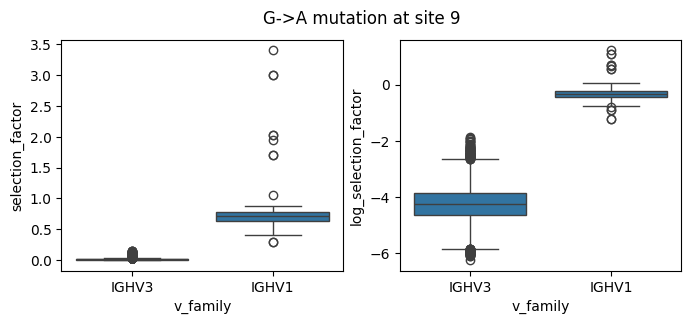

In [21]:
#1
v1_3_site9 = aa_site_subs_selection_df[(aa_site_subs_selection_df['v_family'].isin(['IGHV1', 'IGHV3'])) & (aa_site_subs_selection_df.site == 9)]
print(v1_3_site9[(v1_3_site9.parent_aa == 'G') & (v1_3_site9.selection_factor_target_aa == 'A')].groupby('v_family').size())
# G is the most common aa for v3, but barely appears in v1
# selection factor for the G->A mutation at site 9 in IGHV1 and IGHV3
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))
sns.boxplot(data=v1_3_site9[(v1_3_site9.parent_aa == 'G') & (v1_3_site9.selection_factor_target_aa == 'A')], y='selection_factor', x='v_family', ax=ax1)
sns.boxplot(data=v1_3_site9[(v1_3_site9.parent_aa == 'G') & (v1_3_site9.selection_factor_target_aa == 'A')], y='log_selection_factor', x='v_family', ax=ax2)
fig.suptitle('G->A mutation at site 9')


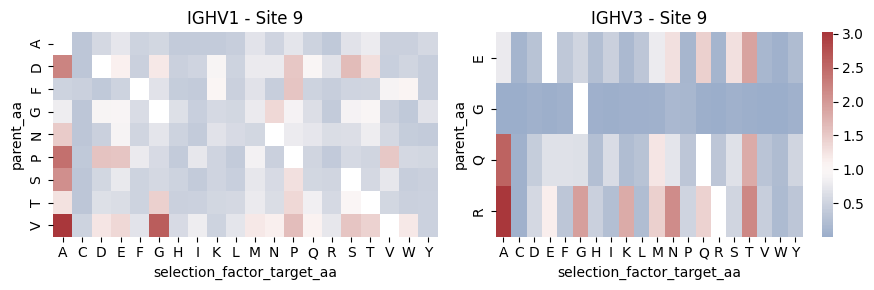

In [22]:
#2
df_temp = v1_3_site9[v1_3_site9.parent_aa.isin(['A', 'G'])].pivot_table(index=['v_family', 'parent_aa'], columns='selection_factor_target_aa', values='selection_factor', aggfunc='median').sort_values(by=['v_family', 'parent_aa'])
# Create separate dataframes for IGHV1 and IGHV3
v1_site9 = v1_3_site9[v1_3_site9['v_family'] == 'IGHV1']
v3_site9 = v1_3_site9[v1_3_site9['v_family'] == 'IGHV3']

# Create pivot tables for each V family
df_v1 = v1_site9.pivot_table(
    index='parent_aa', 
    columns='selection_factor_target_aa', 
    values='selection_factor', 
    aggfunc='median'
).sort_index()

df_v3 = v3_site9.pivot_table(
    index='parent_aa', 
    columns='selection_factor_target_aa', 
    values='selection_factor', 
    aggfunc='median'
).sort_index()

# Plot the heatmaps side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 3))

# IGHV1 heatmap
sns.heatmap(df_v1, cmap="vlag", center=1, ax=ax1, cbar=False, xticklabels=df_v1.columns)
ax1.set_title('IGHV1 - Site 9')


# IGHV3 heatmap
sns.heatmap(df_v3, cmap="vlag", center=1, ax=ax2, xticklabels=df_v3.columns)
ax2.set_title('IGHV3 - Site 9')



plt.tight_layout()
plt.show()

/tmp/ipykernel_3763357/1835003103.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  v1_3_site9['selection_factor_mut'] = v1_3_site9.parent_aa + '>' + v1_3_site9.selection_factor_target_aa


Text(0.5, 0.98, 'G->A mutation at site 9')

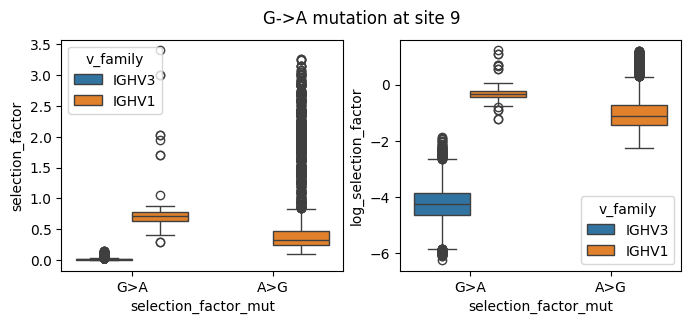

In [23]:
v1_3_site9['selection_factor_mut'] = v1_3_site9.parent_aa + '>' + v1_3_site9.selection_factor_target_aa
# G is the most common aa for v3, but barely appears in v1
# selection factor for the G->A mutation at site 9 in IGHV1 and IGHV3
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))
sns.boxplot(data=v1_3_site9[(v1_3_site9.selection_factor_mut.isin(['A>G', 'G>A']))], x='selection_factor_mut', y='selection_factor', hue='v_family', ax=ax1)
sns.boxplot(data=v1_3_site9[(v1_3_site9.selection_factor_mut.isin(['A>G', 'G>A']))], x='selection_factor_mut', y='log_selection_factor', hue='v_family', ax=ax2)
fig.suptitle('G->A mutation at site 9')



In [24]:
temp_df = aa_site_subs_selection_df[(aa_site_subs_selection_df['v_family'].isin(['IGHV1', 'IGHV3'])) & (aa_site_subs_selection_df.site == 9)].copy()

print(temp_df[temp_df['v_family'] == 'IGHV1']['parent_aa'].value_counts().nlargest(1).index[0])
print(temp_df[temp_df['v_family'] == 'IGHV3']['parent_aa'].value_counts().nlargest(1).index[0])



A
G


100%|██████████| 40/40 [00:38<00:00,  1.03it/s]


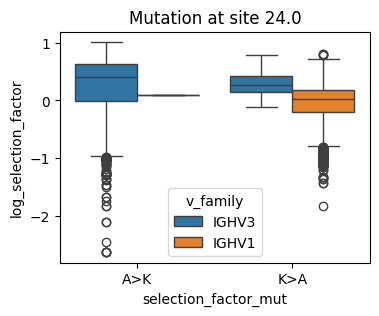

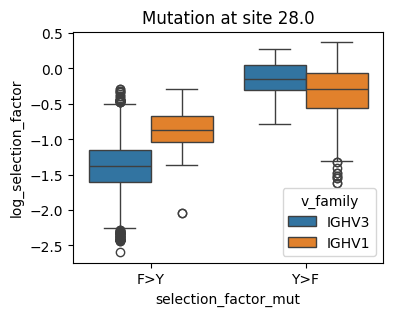

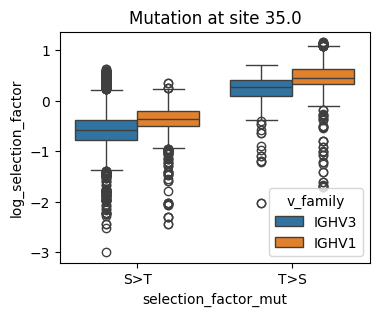

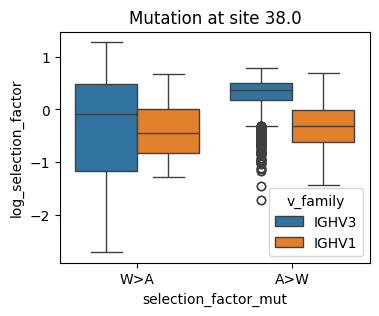

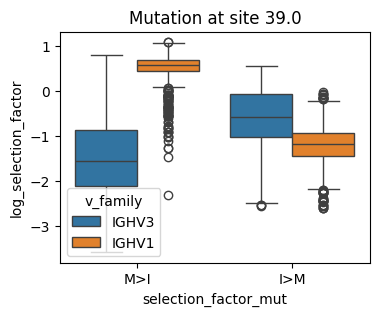

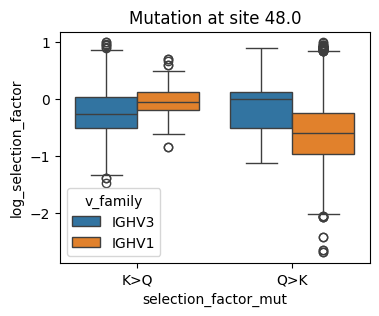

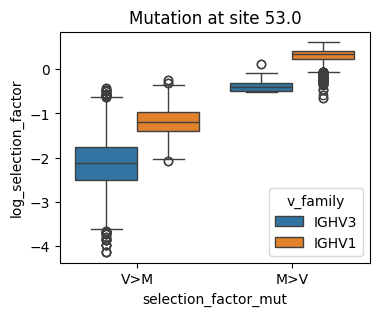

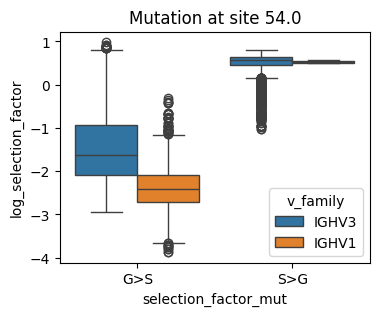

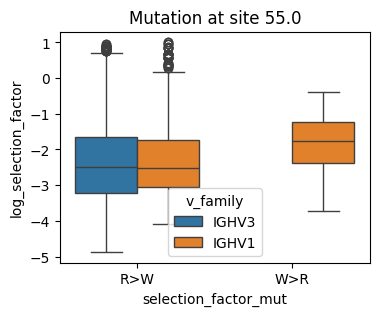

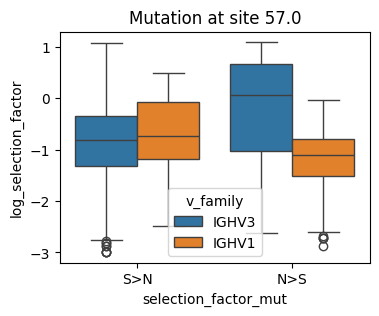

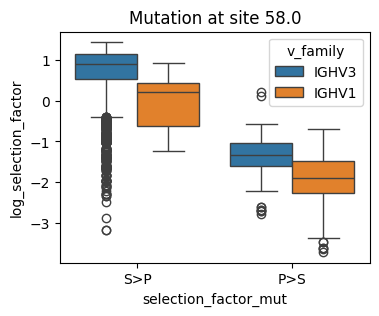

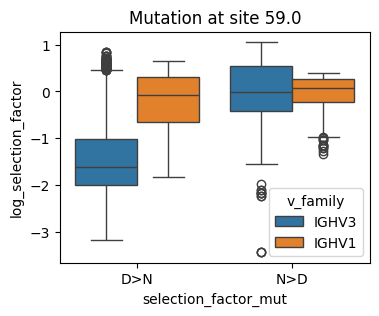

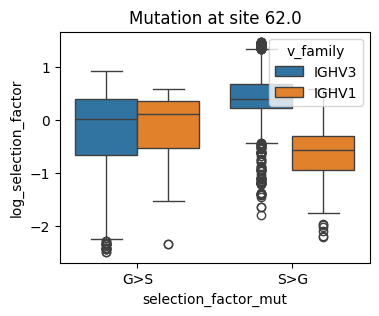

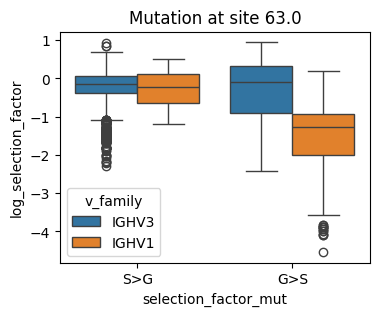

In [25]:
# let's try this on other random sites to see what we get
#diff_df = pd.DataFrame()

for site in tqdm.tqdm(aa_site_subs_selection_df.site.unique()[20:60]):
        temp_df = aa_site_subs_selection_df[(aa_site_subs_selection_df['v_family'].isin(['IGHV1', 'IGHV3'])) & (aa_site_subs_selection_df.site == site)].copy()
        if not temp_df[temp_df['v_family'] == 'IGHV1'].empty and not temp_df[temp_df['v_family'] == 'IGHV3'].empty:
            temp_df['selection_factor_mut'] = temp_df.parent_aa + '>' + temp_df.selection_factor_target_aa
            temp_df = temp_df[temp_df['parent_aa'] != temp_df['selection_factor_target_aa']]
            
            
            #Find most common amino acids by V family
            v1_common = temp_df[temp_df['v_family'] == 'IGHV1']['parent_aa'].value_counts().nlargest(1).index[0]
            v3_common = temp_df[temp_df['v_family'] == 'IGHV3']['parent_aa'].value_counts().nlargest(1).index[0]
            if v1_common != v3_common:
                temp_df = temp_df[(temp_df['parent_aa'].isin([v1_common, v3_common])) & (temp_df['selection_factor_target_aa'].isin([v1_common, v3_common]))]
                
                pivot_temp_df = temp_df.groupby(['v_family', 'selection_factor_mut']).log_selection_factor.median().reset_index().pivot_table(columns='v_family', index='selection_factor_mut', values='log_selection_factor').sort_index()
                pivot_temp_df['log_selection_factor_diff'] = pivot_temp_df['IGHV1'] - pivot_temp_df['IGHV3']
                pivot_temp_df['log_selection_factor_diff_abs'] = pivot_temp_df['log_selection_factor_diff'].abs()
                pivot_temp_df['site'] = site
                #diff_df = pd.concat([diff_df, pivot_temp_df])

                fig, ax = plt.subplots(1, 1, figsize=(4, 3))
                sns.boxplot(data=temp_df, x='selection_factor_mut', y='log_selection_factor', hue='v_family', ax=ax)
                ax.set_title(f'Mutation at site {site}')
                fig.show()



In [27]:
# 2 reciprocal selection factors
# should G>A be the opposite of A>G?


median_log_selection_factors = aa_site_subs_selection_df.groupby(['v_family', 'site', 'parent_aa', 'selection_factor_target_aa']).log_selection_factor.median().reset_index()
median_log_selection_factors

,v_family,site,parent_aa,selection_factor_target_aa,log_selection_factor
0,IGHV1,1.0,A,A,NaN
1,IGHV1,1.0,A,C,-0.333808
2,IGHV1,1.0,A,D,-1.573693
3,IGHV1,1.0,A,E,0.300762
4,IGHV1,1.0,A,F,-0.551753
...,...,...,...,...,...
162135,IGHV7,128.0,S,S,NaN
162136,IGHV7,128.0,S,T,0.382462
162137,IGHV7,128.0,S,V,0.618916
162138,IGHV7,128.0,S,W,-0.699823


In [28]:
median_log_selection_factors_reciprocal = median_log_selection_factors.copy()
median_log_selection_factors_reciprocal.rename(columns={'parent_aa': 'selection_factor_target_aa1','selection_factor_target_aa': 'parent_aa1',}, inplace=True)
median_log_selection_factors_reciprocal.rename(columns={'parent_aa1': 'parent_aa','selection_factor_target_aa1': 'selection_factor_target_aa',}, inplace=True)

median_log_selection_factors_reciprocal = pd.merge(median_log_selection_factors, median_log_selection_factors_reciprocal, on=['v_family', 'site', 'parent_aa', 'selection_factor_target_aa'], how='inner', suffixes=('', '_reciprocal')).sort_values(by='v_family')
median_log_selection_factors_reciprocal['median_log_selection_sum'] = median_log_selection_factors_reciprocal['log_selection_factor'].values + median_log_selection_factors_reciprocal['log_selection_factor_reciprocal'].values
# # check if the selection factors are reciprocal - sum should be 0 if so
# plt.figure(figsize=(4, 3))
# median_log_selection_factors_reciprocal['median_log_selection_sum'].hist(bins=100)
# plt.title('sum of reciprocal log selection factors')

In [29]:
# make sure it's working okay on a specfic example where i know the answer
median_log_selection_factors_reciprocal[median_log_selection_factors_reciprocal.parent_aa < median_log_selection_factors_reciprocal.selection_factor_target_aa][(median_log_selection_factors_reciprocal.site == 53) & (median_log_selection_factors_reciprocal.v_family.isin(['IGHV3'])) & (median_log_selection_factors_reciprocal.parent_aa.isin(['M', 'V'])) & (median_log_selection_factors_reciprocal.selection_factor_target_aa.isin(['M', 'V']))]

/tmp/ipykernel_3763357/1233967778.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  median_log_selection_factors_reciprocal[median_log_selection_factors_reciprocal.parent_aa < median_log_selection_factors_reciprocal.selection_factor_target_aa][(median_log_selection_factors_reciprocal.site == 53) & (median_log_selection_factors_reciprocal.v_family.isin(['IGHV3'])) & (median_log_selection_factors_reciprocal.parent_aa.isin(['M', 'V'])) & (median_log_selection_factors_reciprocal.selection_factor_target_aa.isin(['M', 'V']))]


,v_family,site,parent_aa,selection_factor_target_aa,log_selection_factor,log_selection_factor_reciprocal,median_log_selection_sum
39779,IGHV3,53.0,M,V,-0.413771,-2.13277,-2.546541


In [30]:
median_log_selection_factors_reciprocal[(median_log_selection_factors_reciprocal.site == 9) & (median_log_selection_factors_reciprocal.v_family.isin(['IGHV3']))]

,v_family,site,parent_aa,selection_factor_target_aa,log_selection_factor,log_selection_factor_reciprocal,median_log_selection_sum
34662,IGHV3,9.0,G,R,-4.556691,0.656635,-3.900056
34661,IGHV3,9.0,G,Q,-3.669417,-0.436382,-4.105799
34660,IGHV3,9.0,G,G,NaN,NaN,NaN
34659,IGHV3,9.0,G,E,-3.780326,-0.687610,-4.467937
34658,IGHV3,9.0,E,R,-2.359237,0.126593,-2.232643
34657,IGHV3,9.0,E,Q,0.364132,-0.400271,-0.036139
34656,IGHV3,9.0,E,G,-0.687610,-3.780326,-4.467937
34655,IGHV3,9.0,E,E,NaN,NaN,NaN
34663,IGHV3,9.0,Q,E,-0.400271,0.364132,-0.036139
34664,IGHV3,9.0,Q,G,-0.436382,-3.669417,-4.105799


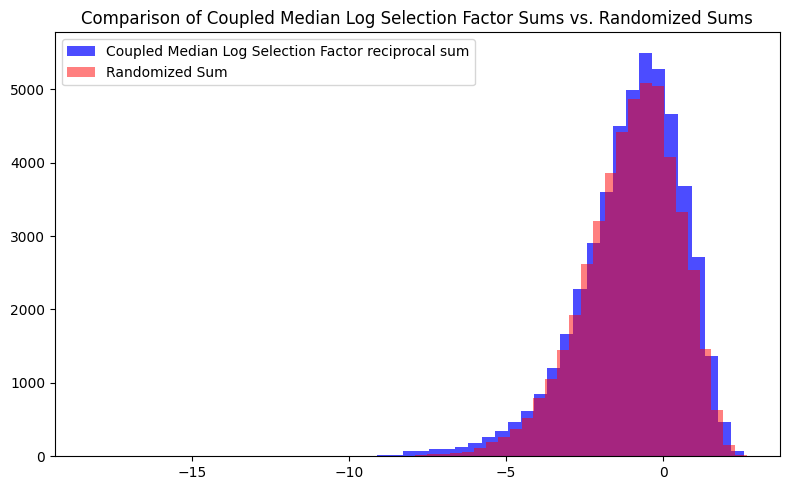

In [31]:
# Drop NaN values for cleaner comparison
clean_df = median_log_selection_factors_reciprocal[median_log_selection_factors_reciprocal.parent_aa < median_log_selection_factors_reciprocal.selection_factor_target_aa].dropna(subset=['log_selection_factor', 'log_selection_factor_reciprocal'])
#clean_df = median_log_selection_factors_reciprocal.dropna(subset=['log_selection_factor', 'log_selection_factor_reciprocal'])


# Original sum
original_sum = clean_df['log_selection_factor'] + clean_df['log_selection_factor_reciprocal']

# Create one randomized sample
np.random.seed(42)  # For reproducibility
randomized_sum = clean_df['log_selection_factor'].sample(frac=1).values + clean_df['log_selection_factor_reciprocal'].values

# Plot both distributions
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(original_sum, bins=50, alpha=0.7, color='blue', label='Coupled Median Log Selection Factor reciprocal sum')
ax.hist(randomized_sum, bins=50, alpha=0.5, color='red', label='Randomized Sum')

ax.set_title('Comparison of Coupled Median Log Selection Factor Sums vs. Randomized Sums')
ax.legend()
plt.tight_layout()
plt.show()


<Figure size 700x500 with 0 Axes>

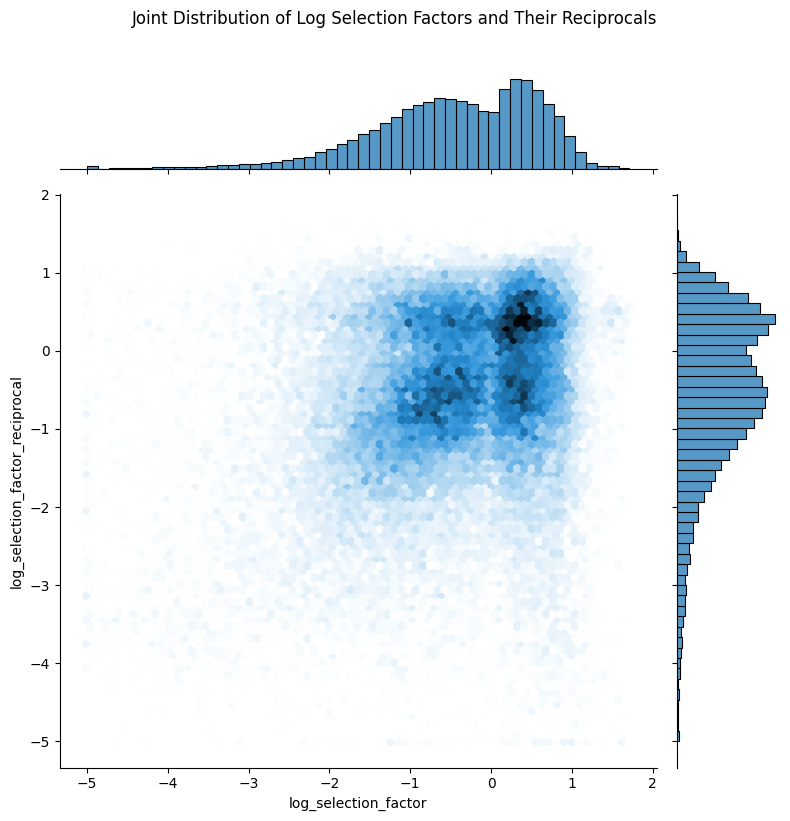

<Figure size 700x500 with 0 Axes>

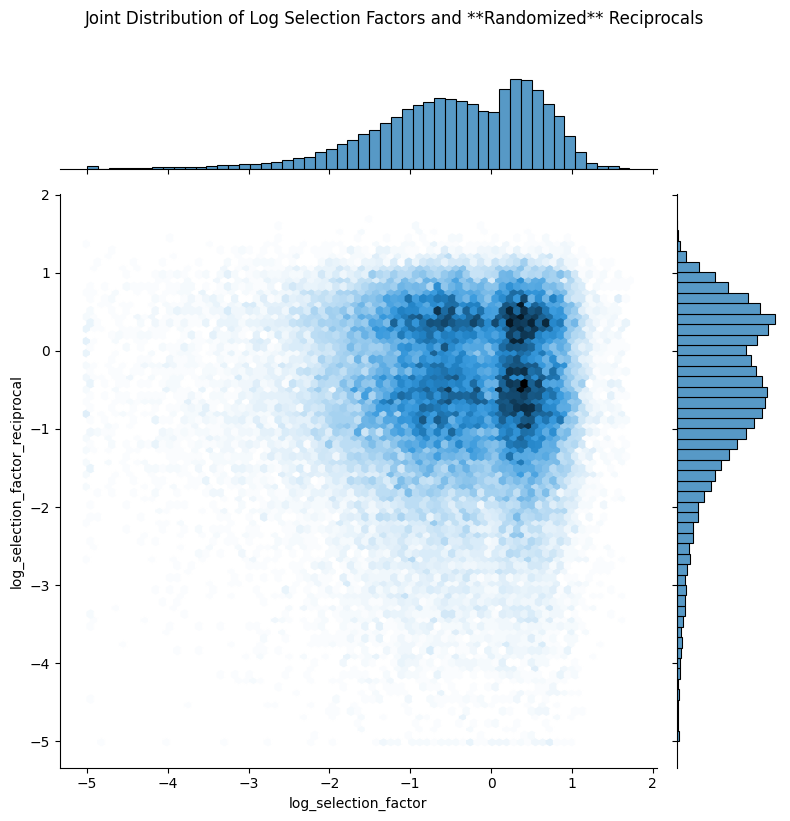

In [32]:
# Trim values below -5 to -5
clean_df_trimmed = clean_df.copy()
clean_df_trimmed['log_selection_factor'] = clean_df_trimmed['log_selection_factor'].clip(lower=-5)
clean_df_trimmed['log_selection_factor_reciprocal'] = clean_df_trimmed['log_selection_factor_reciprocal'].clip(lower=-5)

# Plot for the original coupled data (with trimmed values)
plt.figure(figsize=(7, 5))
g1 = sns.jointplot(data=clean_df_trimmed, x='log_selection_factor', y='log_selection_factor_reciprocal', 
              kind='hex', height=8, gridsize=75,
              marginal_kws=dict(bins=50, fill=True))
plt.suptitle('Joint Distribution of Log Selection Factors and Their Reciprocals', y=1.02)
plt.tight_layout()
plt.show()

# Create randomized version (similar to cell 37)
np.random.seed(42)  # For reproducibility
randomized_df = clean_df_trimmed.copy()
randomized_df['log_selection_factor_reciprocal'] = clean_df_trimmed['log_selection_factor_reciprocal'].sample(frac=1).values

# Plot for the randomized coupled data
plt.figure(figsize=(7, 5))
g2 = sns.jointplot(data=randomized_df, x='log_selection_factor', y='log_selection_factor_reciprocal', 
              kind='hex', height=8, gridsize=75,
              marginal_kws=dict(bins=50, fill=True))
plt.suptitle('Joint Distribution of Log Selection Factors and **Randomized** Reciprocals', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
### look at smaller subsamples

/tmp/ipykernel_30352/3362735250.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  clean_df_trimmed = clean_df[clean_df.parent_aa < clean_df.selection_factor_target_aa][clean_df.log_selection_factor > 0][clean_df.log_selection_factor_reciprocal > 0].copy()


<Figure size 700x500 with 0 Axes>

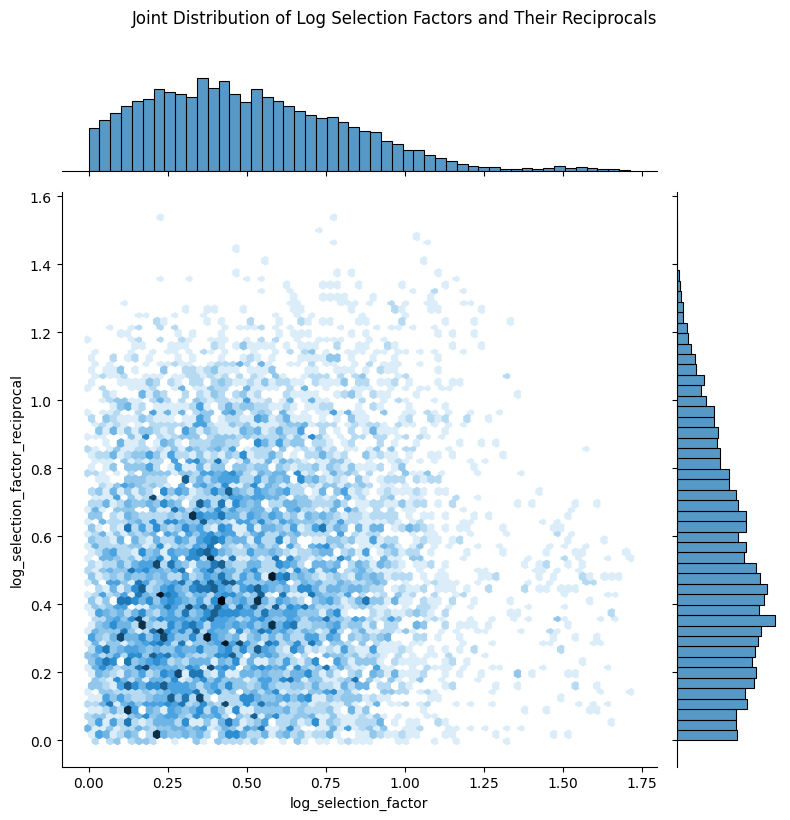

<Figure size 700x500 with 0 Axes>

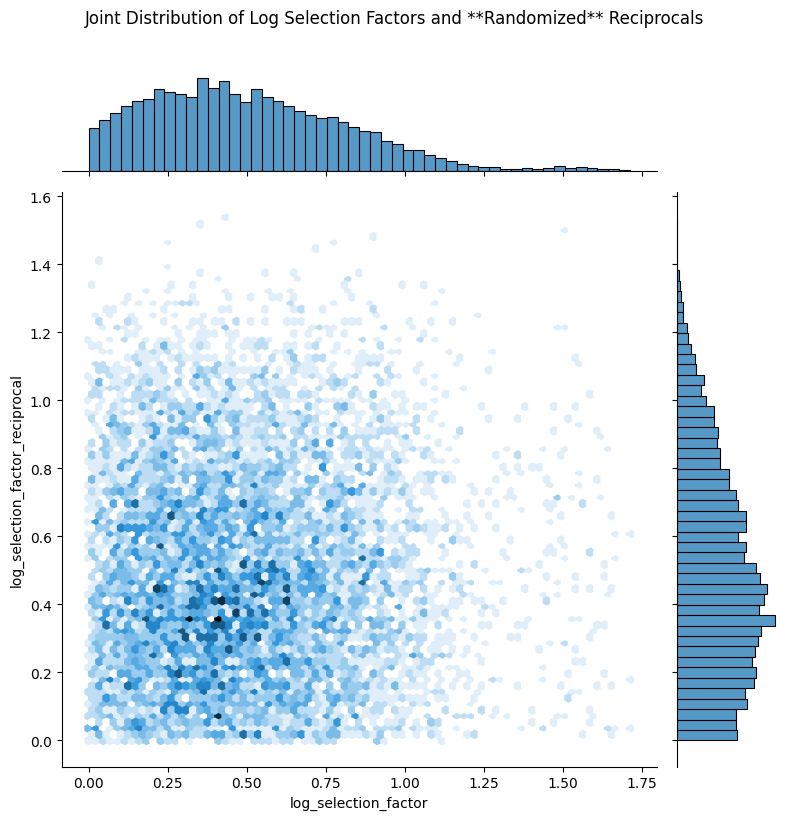

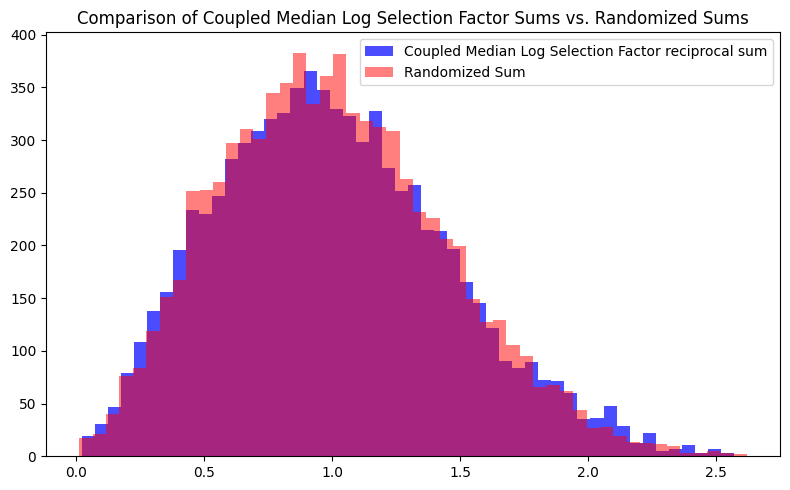

In [ ]:
# Trim values below -5 to -5
#clean_df_trimmed = clean_df[clean_df.parent_aa < clean_df.selection_factor_target_aa][clean_df.site == 9][clean_df.parent_aa.isin(list('A'))].copy()
clean_df_trimmed = clean_df[clean_df.parent_aa < clean_df.selection_factor_target_aa][clean_df.log_selection_factor > 0][clean_df.log_selection_factor_reciprocal > 0].copy()
clean_df_trimmed['log_selection_factor'] = clean_df_trimmed['log_selection_factor'].clip(lower=-5)
clean_df_trimmed['log_selection_factor_reciprocal'] = clean_df_trimmed['log_selection_factor_reciprocal'].clip(lower=-5)

# Plot for the original coupled data (with trimmed values)
plt.figure(figsize=(7, 5))
g1 = sns.jointplot(data=clean_df_trimmed, x='log_selection_factor', y='log_selection_factor_reciprocal', 
              kind='hex', height=8, gridsize=75,
              marginal_kws=dict(bins=50, fill=True))
plt.suptitle('Joint Distribution of Log Selection Factors and Their Reciprocals', y=1.02)
plt.tight_layout()
plt.show()

# Create randomized version (similar to cell 37)
np.random.seed(42)  # For reproducibility
randomized_df = clean_df_trimmed.copy()
randomized_df['log_selection_factor_reciprocal'] = clean_df_trimmed['log_selection_factor_reciprocal'].sample(frac=1).values

# Plot for the randomized coupled data
plt.figure(figsize=(7, 5))
g2 = sns.jointplot(data=randomized_df, x='log_selection_factor', y='log_selection_factor_reciprocal', 
              kind='hex', height=8, gridsize=75,
              marginal_kws=dict(bins=50, fill=True))
plt.suptitle('Joint Distribution of Log Selection Factors and **Randomized** Reciprocals', y=1.02)
plt.tight_layout()
plt.show()

# Original sum
original_sum = clean_df_trimmed['log_selection_factor'] + clean_df_trimmed['log_selection_factor_reciprocal']

# Create one randomized sample
np.random.seed(42)  # For reproducibility
randomized_sum = clean_df_trimmed['log_selection_factor'].sample(frac=1).values + clean_df_trimmed['log_selection_factor_reciprocal'].values

# Plot both distributions
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(original_sum, bins=50, alpha=0.7, color='blue', label='Coupled Median Log Selection Factor reciprocal sum')
ax.hist(randomized_sum, bins=50, alpha=0.5, color='red', label='Randomized Sum')

ax.set_title('Comparison of Coupled Median Log Selection Factor Sums vs. Randomized Sums')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
#### reciprocal selection factor analysis on IGHV3-23*01 - to make sure we are not grouping things that are too different

In [ ]:
aa_site_subs_selection_df[['pcp_index', 'v_gene_h']].drop_duplicates().groupby(['v_gene_h']).size().sort_values(ascending=False)

v_gene_h
IGHV3-23*01      1901
IGHV3-74*01      1082
IGHV4-39*01      1049
IGHV1-69*01      1024
IGHV3-7*01        909
                 ... 
IGHV1-45*02         2
IGHV4-4*09          2
IGHV1-8*02          1
IGHV4-30-4*08       1
IGHV4-61*11         1
Length: 108, dtype: int64

In [ ]:
aa_site_subs_selection_df[aa_site_subs_selection_df.v_gene_h == 'IGHV3-23*01']

,pcp_index,site,selection_factor_target_aa,selection_factor,mutation,is_cdr,parent_codon,parent_aa,child_codon,child_aa,v_gene_h,j_gene,v_family,j_family,sample_id,family,log_selection_factor
780,39,1.0,A,0.569334,False,False,GAG,E,GAG,E,IGHV3-23*01,IGHJ4*02,IGHV3,IGHJ4,sample-igg-SC-24,1117,-0.563289
781,39,1.0,C,1.554492,False,False,GAG,E,GAG,E,IGHV3-23*01,IGHJ4*02,IGHV3,IGHJ4,sample-igg-SC-24,1117,0.441149
782,39,1.0,D,0.822718,False,False,GAG,E,GAG,E,IGHV3-23*01,IGHJ4*02,IGHV3,IGHJ4,sample-igg-SC-24,1117,-0.195142
783,39,1.0,E,NaN,False,False,GAG,E,GAG,E,IGHV3-23*01,IGHJ4*02,IGHV3,IGHJ4,sample-igg-SC-24,1117,NaN
784,39,1.0,F,0.506571,False,False,GAG,E,GAG,E,IGHV3-23*01,IGHJ4*02,IGHV3,IGHJ4,sample-igg-SC-24,1117,-0.680090
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52926615,21711,128.0,S,NaN,False,False,TCA,S,TCA,S,IGHV3-23*01,IGHJ6*03,IGHV3,IGHJ6,sample-igg-W-75,229,NaN
52926616,21711,128.0,T,1.411932,False,False,TCA,S,TCA,S,IGHV3-23*01,IGHJ6*03,IGHV3,IGHJ6,sample-igg-W-75,229,0.344959
52926617,21711,128.0,V,2.091472,False,False,TCA,S,TCA,S,IGHV3-23*01,IGHJ6*03,IGHV3,IGHJ6,sample-igg-W-75,229,0.737868
52926618,21711,128.0,W,0.345507,False,False,TCA,S,TCA,S,IGHV3-23*01,IGHJ6*03,IGHV3,IGHJ6,sample-igg-W-75,229,-1.062741


In [ ]:
median_log_selection_factors = aa_site_subs_selection_df[aa_site_subs_selection_df.v_gene_h == 'IGHV3-23*01'].groupby(['v_family', 'site', 'parent_aa', 'selection_factor_target_aa', 'is_cdr']).log_selection_factor.median().reset_index()
median_log_selection_factors_reciprocal = median_log_selection_factors.copy()
median_log_selection_factors_reciprocal.rename(columns={'parent_aa': 'selection_factor_target_aa1','selection_factor_target_aa': 'parent_aa1',}, inplace=True)
median_log_selection_factors_reciprocal.rename(columns={'parent_aa1': 'parent_aa','selection_factor_target_aa1': 'selection_factor_target_aa',}, inplace=True)

median_log_selection_factors_reciprocal = pd.merge(median_log_selection_factors, median_log_selection_factors_reciprocal, on=['v_family', 'site', 'parent_aa', 'selection_factor_target_aa', 'is_cdr'], how='inner', suffixes=('', '_reciprocal')).sort_values(by='v_family')
median_log_selection_factors_reciprocal['median_log_selection_sum'] = median_log_selection_factors_reciprocal['log_selection_factor'].values + median_log_selection_factors_reciprocal['log_selection_factor_reciprocal'].values



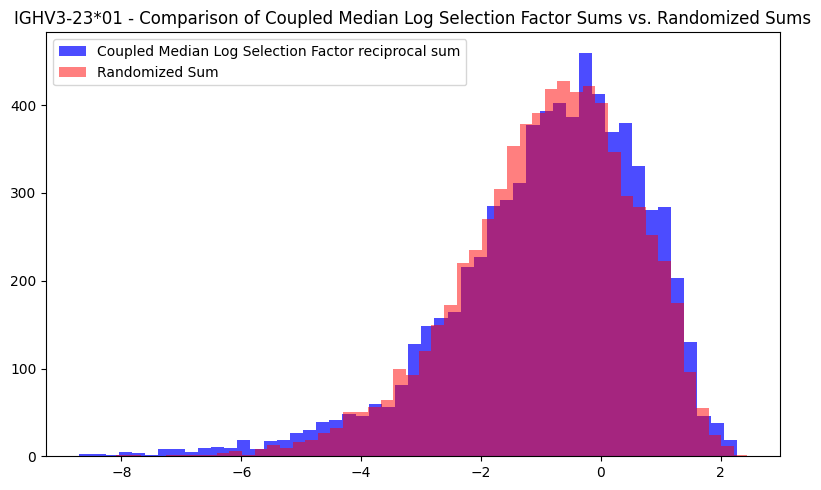

In [ ]:
# Drop NaN values for cleaner comparison
clean_df = median_log_selection_factors_reciprocal[median_log_selection_factors_reciprocal.parent_aa < median_log_selection_factors_reciprocal.selection_factor_target_aa].dropna(subset=['log_selection_factor', 'log_selection_factor_reciprocal'])
#clean_df = median_log_selection_factors_reciprocal.dropna(subset=['log_selection_factor', 'log_selection_factor_reciprocal'])


# Original sum
original_sum = clean_df['log_selection_factor'] + clean_df['log_selection_factor_reciprocal']

# Create one randomized sample
np.random.seed(42)  # For reproducibility
randomized_sum = clean_df['log_selection_factor'].sample(frac=1).values + clean_df['log_selection_factor_reciprocal'].values

# Plot both distributions
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(original_sum, bins=50, alpha=0.7, color='blue', label='Coupled Median Log Selection Factor reciprocal sum')
ax.hist(randomized_sum, bins=50, alpha=0.5, color='red', label='Randomized Sum')

ax.set_title('IGHV3-23*01 - Comparison of Coupled Median Log Selection Factor Sums vs. Randomized Sums')
ax.legend()
plt.tight_layout()
plt.show()


<Figure size 700x500 with 0 Axes>

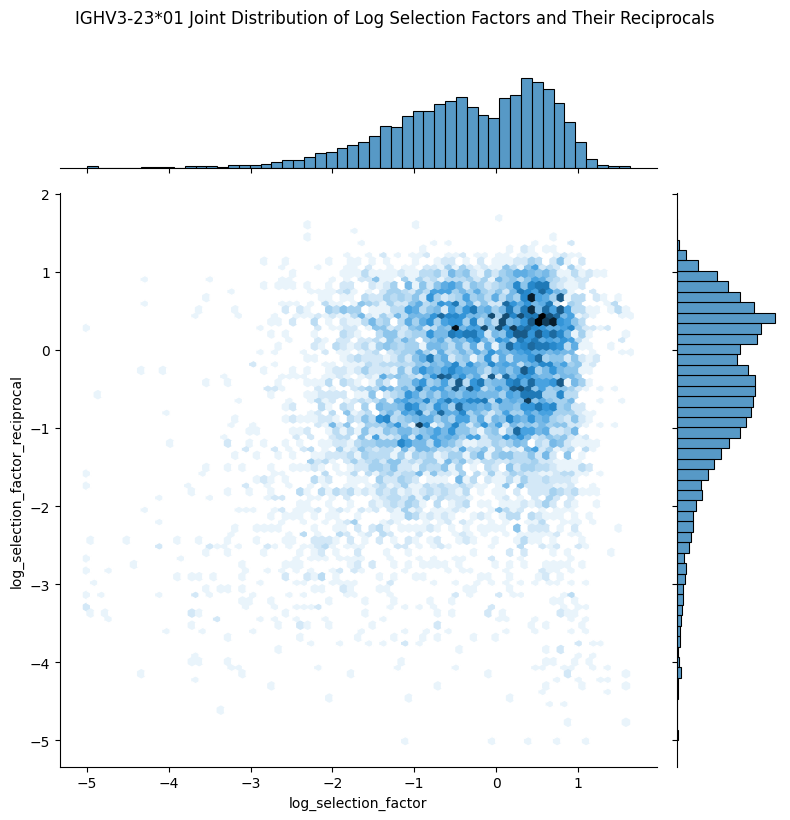

<Figure size 700x500 with 0 Axes>

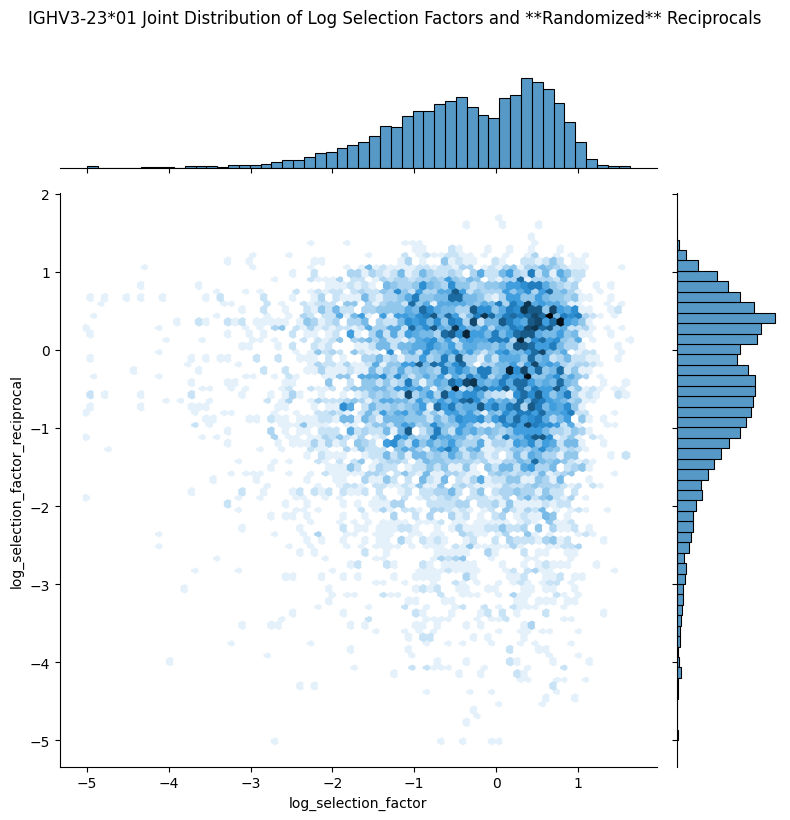

In [ ]:
# Drop NaN values for cleaner comparison
clean_df = median_log_selection_factors_reciprocal[median_log_selection_factors_reciprocal.parent_aa < median_log_selection_factors_reciprocal.selection_factor_target_aa].dropna(subset=['log_selection_factor', 'log_selection_factor_reciprocal'])
#clean_df = median_log_selection_factors_reciprocal.dropna(subset=['log_selection_factor', 'log_selection_factor_reciprocal'])


# Trim values below -5 to -5
clean_df_trimmed = clean_df.copy()
clean_df_trimmed['log_selection_factor'] = clean_df_trimmed['log_selection_factor'].clip(lower=-5)
clean_df_trimmed['log_selection_factor_reciprocal'] = clean_df_trimmed['log_selection_factor_reciprocal'].clip(lower=-5)

# Plot for the original coupled data (with trimmed values)
plt.figure(figsize=(7, 5))
g1 = sns.jointplot(data=clean_df_trimmed, x='log_selection_factor', y='log_selection_factor_reciprocal', 
              kind='hex', height=8, gridsize=75,
              marginal_kws=dict(bins=50, fill=True))
plt.suptitle('IGHV3-23*01 Joint Distribution of Log Selection Factors and Their Reciprocals', y=1.02)
plt.tight_layout()
plt.show()

# Create randomized version (similar to cell 37)
np.random.seed(42)  # For reproducibility
randomized_df = clean_df_trimmed.copy()
randomized_df['log_selection_factor_reciprocal'] = clean_df_trimmed['log_selection_factor_reciprocal'].sample(frac=1).values

# Plot for the randomized coupled data
plt.figure(figsize=(7, 5))
g2 = sns.jointplot(data=randomized_df, x='log_selection_factor', y='log_selection_factor_reciprocal', 
              kind='hex', height=8, gridsize=75,
              marginal_kws=dict(bins=50, fill=True))
plt.suptitle('IGHV3-23*01 Joint Distribution of Log Selection Factors and **Randomized** Reciprocals', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
#### for this ighv3-23*01, let's separate into cdr and non cdr sites and see if the selection factors are different

In [ ]:
clean_df_trimmed_noncdr

,v_family,site,parent_aa,selection_factor_target_aa,is_cdr,log_selection_factor,log_selection_factor_reciprocal,median_log_selection_sum


<Figure size 600x400 with 0 Axes>

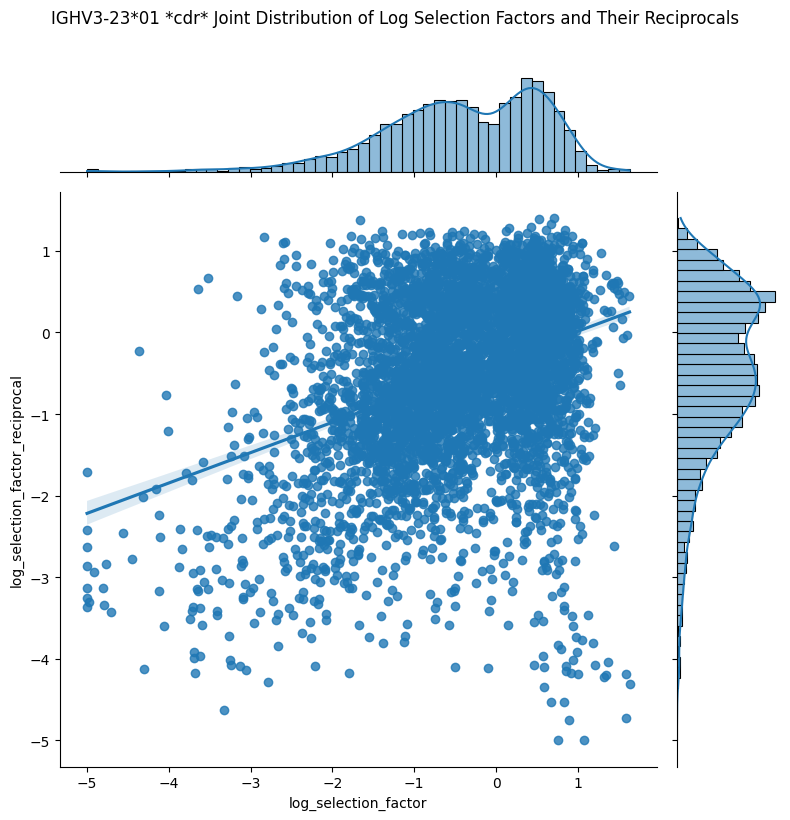

<Figure size 600x400 with 0 Axes>

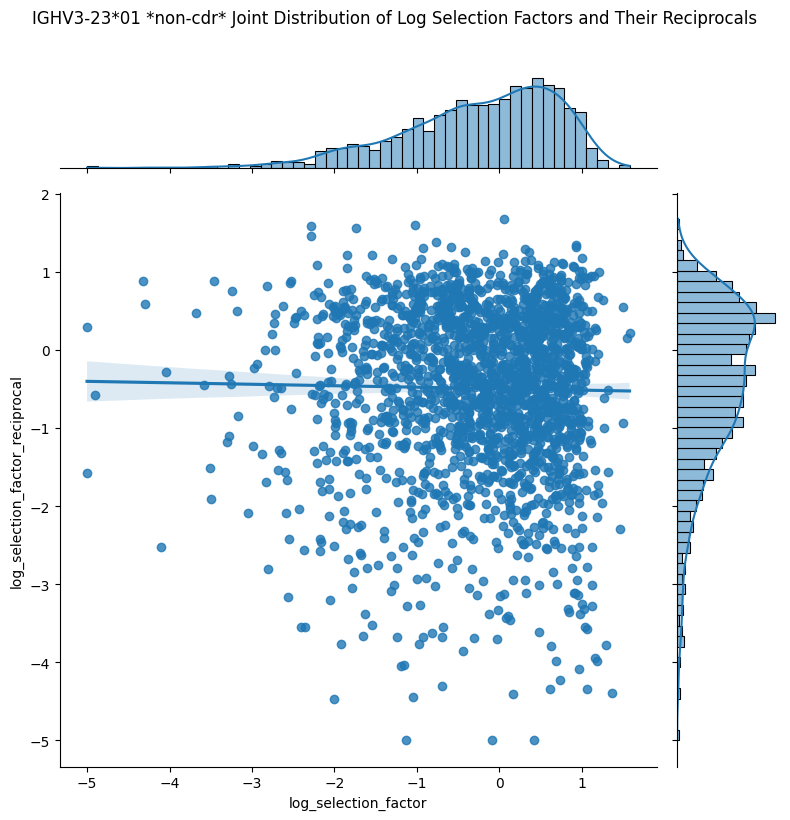

In [ ]:
clean_df = median_log_selection_factors_reciprocal[median_log_selection_factors_reciprocal.parent_aa < median_log_selection_factors_reciprocal.selection_factor_target_aa].dropna(subset=['log_selection_factor', 'log_selection_factor_reciprocal'])

clean_df_trimmed_cdr = clean_df[clean_df.is_cdr == True].copy()
clean_df_trimmed_noncdr = clean_df[clean_df.is_cdr == False].copy()

for (title, clean_df) in zip(['cdr', 'non-cdr'], [clean_df_trimmed_cdr, clean_df_trimmed_noncdr]):
    # Trim values below -5 to -5
    clean_df_trimmed = clean_df.copy()
    clean_df_trimmed['log_selection_factor'] = clean_df_trimmed['log_selection_factor'].clip(lower=-5)
    clean_df_trimmed['log_selection_factor_reciprocal'] = clean_df_trimmed['log_selection_factor_reciprocal'].clip(lower=-5)

    # Plot for the original coupled data (with trimmed values)
    plt.figure(figsize=(6, 4))
    g1 = sns.jointplot(data=clean_df_trimmed, x='log_selection_factor', y='log_selection_factor_reciprocal', 
                kind='reg', height=8, #gridsize=75,
                marginal_kws=dict(bins=50, fill=True,))
    plt.suptitle(f'IGHV3-23*01 *{title}* Joint Distribution of Log Selection Factors and Their Reciprocals', y=1.02)
    plt.tight_layout()
    plt.show()

    # # Create randomized version (similar to cell 37)
    # np.random.seed(42)  # For reproducibility
    # randomized_df = clean_df_trimmed.copy()
    # randomized_df['log_selection_factor_reciprocal'] = clean_df_trimmed['log_selection_factor_reciprocal'].sample(frac=1).values

    # # Plot for the randomized coupled data
    # plt.figure(figsize=(6, 4))
    # g2 = sns.jointplot(data=randomized_df, x='log_selection_factor', y='log_selection_factor_reciprocal', 
    #             kind='hex', height=8, gridsize=75,
    #             marginal_kws=dict(bins=50, fill=True))
    # plt.suptitle(f'IGHV3-23*01 *{title}* Joint Distribution of Log Selection Factors and **Randomized** Reciprocals', y=1.02)
    # plt.tight_layout()
    # plt.show()


<Axes: >

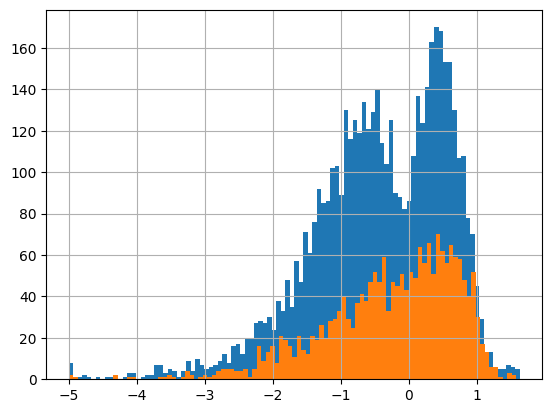

In [ ]:
clean_df_trimmed_cdr.log_selection_factor.hist(bins=100, label='cdr')
clean_df_trimmed_noncdr.log_selection_factor.hist(bins=100, label='cdr')

In [ ]:
## compare v3 and v4


In [ ]:
median_log_selection_factors_V4 = aa_site_subs_selection_df[aa_site_subs_selection_df.v_family == 'IGHV4'].groupby(['site', 'parent_aa', 'selection_factor_target_aa']).log_selection_factor.median().reset_index().copy()
median_log_selection_factors_V3 = aa_site_subs_selection_df[aa_site_subs_selection_df.v_family == 'IGHV3'].groupby(['site', 'parent_aa', 'selection_factor_target_aa']).log_selection_factor.median().reset_index().copy()



median_log_selection_factors_reciprocal.rename(columns={'parent_aa': 'selection_factor_target_aa1','selection_factor_target_aa': 'parent_aa1',}, inplace=True)
median_log_selection_factors_reciprocal.rename(columns={'parent_aa1': 'parent_aa','selection_factor_target_aa1': 'selection_factor_target_aa',}, inplace=True)

median_log_selection_factors_V3V4 = pd.merge(median_log_selection_factors_V3, median_log_selection_factors_V4, on=['site', 'parent_aa', 'selection_factor_target_aa'], how='inner', suffixes=('_V3', '_V4'))

median_log_selection_factors_V3V4


,site,parent_aa,selection_factor_target_aa,log_selection_factor_V3,log_selection_factor_V4
0,1.0,E,A,-0.980271,-0.929799
1,1.0,E,C,0.386767,-0.281314
2,1.0,E,D,-0.665365,-0.810593
3,1.0,E,E,NaN,NaN
4,1.0,E,F,-1.244644,-0.948123
...,...,...,...,...,...
26735,128.0,V,S,-1.677417,-2.521430
26736,128.0,V,T,-0.521480,-1.355172
26737,128.0,V,V,NaN,NaN
26738,128.0,V,W,-0.490486,-1.716618


In [ ]:
median_log_selection_factors_V3V4[median_log_selection_factors_V3V4.site == 53][median_log_selection_factors_V3V4.parent_aa.isin(['M', 'V']) & median_log_selection_factors_V3V4.selection_factor_target_aa.isin(['M', 'V'])]

/tmp/ipykernel_9052/106468245.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  median_log_selection_factors_V3V4[median_log_selection_factors_V3V4.site == 53][median_log_selection_factors_V3V4.parent_aa.isin(['M', 'V']) & median_log_selection_factors_V3V4.selection_factor_target_aa.isin(['M', 'V'])]


,site,parent_aa,selection_factor_target_aa,log_selection_factor_V3,log_selection_factor_V4
7150,53.0,M,M,NaN,NaN
7157,53.0,M,V,-0.413771,-0.678910
7190,53.0,V,M,-2.132770,-1.327274
7197,53.0,V,V,NaN,NaN


In [ ]:
median_log_selection_factors_V3V4

,site,parent_aa,selection_factor_target_aa,log_selection_factor_V3,log_selection_factor_V4
0,1.0,E,A,-0.980271,-0.929799
1,1.0,E,C,0.386767,-0.281314
2,1.0,E,D,-0.665365,-0.810593
3,1.0,E,E,NaN,NaN
4,1.0,E,F,-1.244644,-0.948123
...,...,...,...,...,...
26735,128.0,V,S,-1.677417,-2.521430
26736,128.0,V,T,-0.521480,-1.355172
26737,128.0,V,V,NaN,NaN
26738,128.0,V,W,-0.490486,-1.716618


<Figure size 700x500 with 0 Axes>

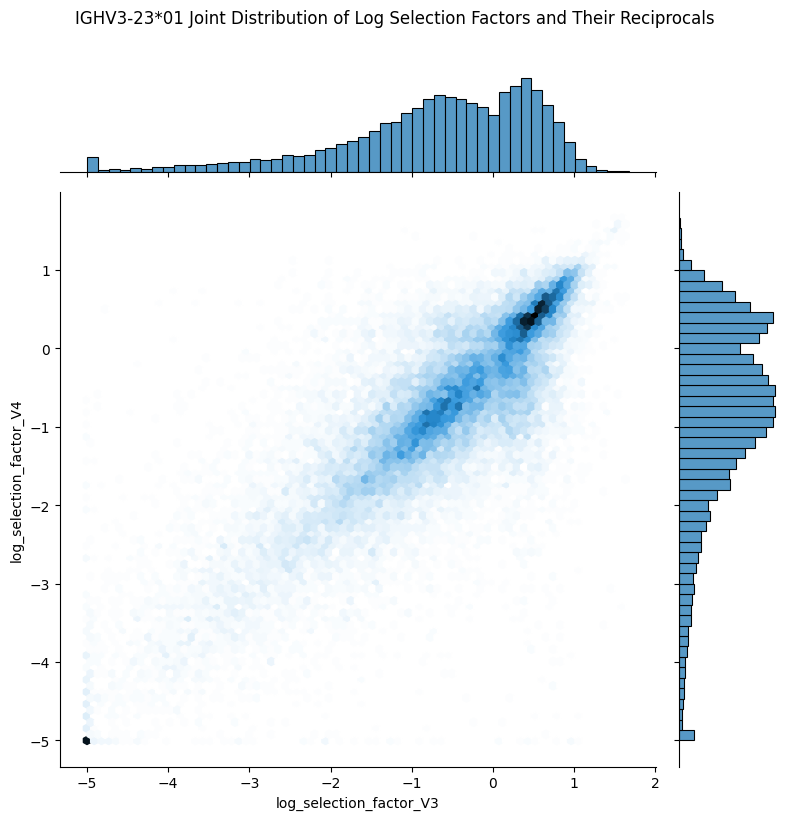

<Figure size 700x500 with 0 Axes>

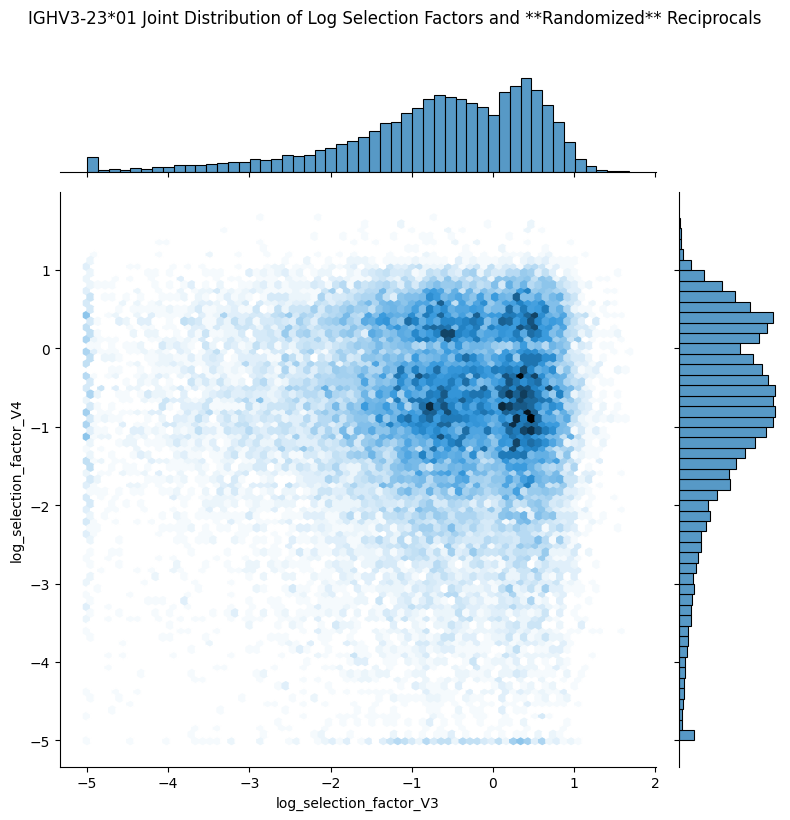

In [ ]:
# Drop NaN values for cleaner comparison
#clean_df = median_log_selection_factors_V3V4[median_log_selection_factors_V3V4.parent_aa < median_log_selection_factors_V3V4.selection_factor_target_aa].dropna(subset=['log_selection_factor_V3', 'log_selection_factor_V4'])
clean_df = median_log_selection_factors_V3V4.dropna(subset=['log_selection_factor_V3', 'log_selection_factor_V4'])


# Trim values below -5 to -5
clean_df_trimmed = clean_df.copy()
clean_df_trimmed['log_selection_factor_V3'] = clean_df_trimmed['log_selection_factor_V3'].clip(lower=-5)
clean_df_trimmed['log_selection_factor_V4'] = clean_df_trimmed['log_selection_factor_V4'].clip(lower=-5)

# Plot for the original coupled data (with trimmed values)
plt.figure(figsize=(7, 5))
g1 = sns.jointplot(data=clean_df_trimmed, x='log_selection_factor_V3', y='log_selection_factor_V4', 
              kind='hex', height=8, gridsize=75,
              marginal_kws=dict(bins=50, fill=True))
plt.suptitle('V3 vs V4 Joint Distribution of Log Selection Factors and Their Reciprocals', y=1.02)
plt.tight_layout()
plt.show()

# Create randomized version (similar to cell 37)
np.random.seed(42)  # For reproducibility
randomized_df = clean_df_trimmed.copy()
randomized_df['log_selection_factor_V4'] = clean_df_trimmed['log_selection_factor_V4'].sample(frac=1).values

# Plot for the randomized coupled data
plt.figure(figsize=(7, 5))
g2 = sns.jointplot(data=randomized_df, x='log_selection_factor_V3', y='log_selection_factor_V4', 
              kind='hex', height=8, gridsize=75,
              marginal_kws=dict(bins=50, fill=True))
plt.suptitle('V3 vs V4 Joint Distribution of Log Selection Factors and **Randomized** Reciprocals', y=1.02)
plt.tight_layout()
plt.show()

### let's try grouping focusing on only one v gene, IGHV3-23*01, to make sure we aren't grouping too broadly


aa_site_subs_selection_df[['pcp_index', 'v_gene_h']].drop_duplicates().groupby(['v_gene_h']).size()

### let's try grouping focusing on only one v gene, IGHV3-23*01, to make sure we aren't grouping too broadly

# 2 reciprocal selection factors
# should G>A be the opposite of A>G?

median_log_selection_factors = aa_site_subs_selection_df[aa_site_subs_selection_df.v_gene_h == 'IGHV3-23*01'].groupby(['v_family', 'site', 'parent_aa', 'selection_factor_target_aa']).log_selection_factor.median().reset_index()
median_log_selection_factors


median_log_selection_factors_reciprocal = median_log_selection_factors.copy()
median_log_selection_factors_reciprocal.rename(columns={'parent_aa': 'selection_factor_target_aa1','selection_factor_target_aa': 'parent_aa1',}, inplace=True)
median_log_selection_factors_reciprocal.rename(columns={'parent_aa1': 'parent_aa','selection_factor_target_aa1': 'selection_factor_target_aa',}, inplace=True)

median_log_selection_factors_reciprocal = pd.merge(median_log_selection_factors, median_log_selection_factors_reciprocal, on=['v_family', 'site', 'parent_aa', 'selection_factor_target_aa'], how='outer', suffixes=('', '_reciprocal')).sort_values(by='v_family')
median_log_selection_factors_reciprocal['median_log_selection_sum'] = median_log_selection_factors_reciprocal['log_selection_factor'].values + median_log_selection_factors_reciprocal['log_selection_factor_reciprocal'].values
# check if the selection factors are reciprocal - sum should be 0 if so
plt.figure(figsize=(4, 3))
median_log_selection_factors_reciprocal['median_log_selection_sum'].hist(bins=100)
plt.title('sum of reciprocal log selection factors')
# Drop NaN values for cleaner comparison
clean_df = median_log_selection_factors_reciprocal.dropna(subset=['log_selection_factor', 'log_selection_factor_reciprocal'])

# Original sum
original_sum = clean_df['log_selection_factor'] + clean_df['log_selection_factor_reciprocal']

# Create one randomized sample
np.random.seed(42)  # For reproducibility
randomized_sum = clean_df['log_selection_factor'].sample(frac=1).values + clean_df['log_selection_factor_reciprocal'].values

# Plot both distributions
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(original_sum, bins=50, alpha=0.7, color='blue', label='Coupled Median Log Selection Factor reciprocal sum')
ax.hist(randomized_sum, bins=50, alpha=0.5, color='red', label='Randomized Sum')

ax.set_title('Comparison of Coupled Median Log Selection Factor Sums vs. Randomized Sums')
ax.legend()
plt.tight_layout()
plt.show()


sns.jointplot(data=clean_df, x='log_selection_factor', y='log_selection_factor_reciprocal', kind='hex')

import seaborn as sns

# Plot for the original coupled data
plt.figure(figsize=(10, 8))
sns.jointplot(data=clean_df, x='log_selection_factor', y='log_selection_factor_reciprocal', 
              kind='hex', height=8, cmap='viridis',
              marginal_kws=dict(bins=50, fill=True))
plt.suptitle('Joint Distribution of Log Selection Factors and Their Reciprocals', y=1.02)
plt.tight_layout()
plt.show()

# Create randomized version (similar to cell 37)
np.random.seed(42)  # For reproducibility
randomized_df = clean_df.copy()
randomized_df['log_selection_factor_reciprocal'] = clean_df['log_selection_factor_reciprocal'].sample(frac=1).values

# Plot for the randomized coupled data
plt.figure(figsize=(10, 8))
sns.jointplot(data=randomized_df, x='log_selection_factor', y='log_selection_factor_reciprocal', 
              kind='hex', height=8, cmap='viridis',
              marginal_kws=dict(bins=50, fill=True))
plt.suptitle('Joint Distribution of Log Selection Factors and Randomized Reciprocals', y=1.02)
plt.tight_layout()
plt.show()

## compare V and J gene families selection factors

## Vanwinkle data

datasets in names datasets had a lot of N's in them, so I used this to filter:

(netam_env) nharel@ermine:~/re$ python pcp-pipeline/scripts/filter_pcp_with_N_and_naive.py ~/data/v1/vanwinkle-170-igh_pcp_2025-03-05_MASKED_NI_test_no-naive_DXSMVALID.csv.gz 
Saved to: /home/nharel/data/v1/vanwinkle-170-igh_pcp_2025-03-05_MASKED_NI_test_no-naive_DXSMVALID_noN_no-naive.csv.gz

also add branch length calculation

dataset_name = "v1vanwinkleheavyTestnoN"
model_name = "dnsm_1m-v1jaffe+v1tang-joint"

crepe_prefix = localify(f"DNSM_TRAINED_MODELS_DIR/{model_name}")
test_output_prefix = localify(f"DNSM_TEST_OUTPUT_DIR/{model_name}-ON-{dataset_name}")

if not os.path.exists(f"{test_output_prefix}.branch_lengths_csv"):
    dnsm_zoo.write_branch_lengths("/fh/fast/matsen_e/shared/bcr-mut-sel/dnsm/dnsm-experiments-1/dnsm-train/trained_models/dnsm_1m-v1jaffe+v1tang-joint", "v1vanwinkleheavyTestnoN", f"{test_output_prefix}.branch_lengths_csv")

    # when trying to run this, I got an error about not being in the anarci dict. so I added the same entry as the 
    #     "v1vanwinkleheavyTestnoN": "DATA_DIR/anarci/vanwinkle-170-igh_anarci-seqs_imgt_H_patch.csv", is this okay??
complete_plotter, plotter_dict = write_sites_oe(
    crepe_prefix=crepe_prefix,
    dataset_name=dataset_name,
    #branch_length_path=f"/fh/fast/matsen_e/wdumm/for_noam/dnsm_1m-v1jaffe+v1tang-joint_ON_v1vanwinkleheavyTest_branch_lengths_csv",
    branch_length_path=f"{test_output_prefix}.branch_lengths_csv",
    csv_output_path=f"{test_output_prefix}-sites-oe.csv",
    v_families=["IGHV1", "IGHV2", "IGHV3", "IGHV4", "IGHV5", "IGHV6", "IGHV7"],
    fig_out_path=f"{figures_dir}/sites-oe-V1,3,4.svg",
    min_log_prob=-4,
    replace_title=True,
)
complete_plotter = complete_plotter["h"]